# 동학개미는 정말 이겼을까: 5년치 순매수 데이터의 답

## 3. 백테스트: 개미 포트폴리오 vs 코스피

### 전략 정의

**개미 포트폴리오 전략**: 매년 초, 전년도 개인 순매수 상위 10종목을 동일 비중(각 10%)으로 매수하여 연말에 매도

**벤치마크**: 같은 금액을 코스피 ETF에 투자

### 왜 "전년도" 순매수 기준인가?
실제 투자자는 연말 순매수 데이터를 연초에 확인 가능. 미래를 볼 수 없으므로, 전년도 데이터를 기준으로 다음 해 포트폴리오를 구성하는 것이 현실적.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# 한글 폰트 설정
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()
fm.fontManager.addfont(font_path)
mpl.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style("whitegrid", {"font.family": font_name})

# 데이터 로드
top_stocks = pd.read_csv('../data/top_stocks.csv')
prices = pd.read_csv('../data/prices.csv')
kospi = pd.read_csv('../data/kospi.csv')

prices['날짜'] = pd.to_datetime(prices['날짜'])
prices['ticker'] = prices['ticker'].astype(str).str.zfill(6)
kospi['날짜'] = pd.to_datetime(kospi['날짜'])

print("데이터 로드 완료")

데이터 로드 완료


## 1. 개미 포트폴리오 연간 수익률 계산

전략:
- 2020년 순매수 상위 10종목 → **2021년** 보유
- 2021년 순매수 상위 10종목 → **2022년** 보유
- ...
- 2024년 순매수 상위 10종목 → **2025년** 보유

각 종목 동일 비중(10%)으로 투자, 연초 첫 거래일 매수 → 연말 마지막 거래일 매도

In [2]:
# 개미 포트폴리오 백테스트
TOP_N = 10
results = []

for buy_year in [2020, 2021, 2022, 2023, 2024]:
    hold_year = buy_year + 1  # 다음 해에 보유
    
    # 전년도 순매수 상위 N종목
    portfolio = top_stocks[top_stocks['year'] == buy_year].head(TOP_N)
    
    # 코스피 연간 수익률
    kospi_year = kospi[kospi['날짜'].dt.year == hold_year].sort_values('날짜')
    if len(kospi_year) < 2:
        continue
    kospi_ret = (kospi_year['종가'].iloc[-1] / kospi_year['종가'].iloc[0] - 1) * 100
    
    # 각 종목의 보유 연도 수익률
    stock_returns = []
    
    for _, row in portfolio.iterrows():
        stock_data = prices[
            (prices['ticker'] == row['종목코드']) &
            (prices['날짜'].dt.year == hold_year)
        ].sort_values('날짜')
        
        if len(stock_data) < 2:
            continue
        
        ret = (stock_data['종가'].iloc[-1] / stock_data['종가'].iloc[0] - 1) * 100
        stock_returns.append({
            '종목명': row['종목명'],
            'ticker': row['종목코드'],
            '수익률': ret,
            '코스피초과': ret - kospi_ret
        })
    
    # 동일 비중 포트폴리오 수익률 (평균)
    if stock_returns:
        port_ret = np.mean([s['수익률'] for s in stock_returns])
        
        results.append({
            '기준연도': buy_year,
            '보유연도': hold_year,
            '포트폴리오수익률': port_ret,
            '코스피수익률': kospi_ret,
            '초과수익률': port_ret - kospi_ret,
            '종목수': len(stock_returns),
            '코스피초과종목수': sum(1 for s in stock_returns if s['수익률'] > kospi_ret),
            '종목상세': stock_returns
        })

results_df = pd.DataFrame(results)

print("=" * 60)
print("개미 포트폴리오 vs 코스피 (연간 성과)")
print("=" * 60)
print(f"\n{'보유연도':<10} {'개미':>10} {'코스피':>10} {'초과':>10} {'승률':>8}")
print("-" * 50)

for _, r in results_df.iterrows():
    win = f"{r['코스피초과종목수']:.0f}/{r['종목수']:.0f}"
    print(f"{r['보유연도']:.0f}년     {r['포트폴리오수익률']:>+8.1f}%  {r['코스피수익률']:>+8.1f}%  {r['초과수익률']:>+8.1f}%  {win:>8}")

avg_port = results_df['포트폴리오수익률'].mean()
avg_kospi = results_df['코스피수익률'].mean()
print("-" * 50)
print(f"{'평균':<10} {avg_port:>+8.1f}%  {avg_kospi:>+8.1f}%  {avg_port - avg_kospi:>+8.1f}%")

개미 포트폴리오 vs 코스피 (연간 성과)

보유연도               개미        코스피         초과       승률
--------------------------------------------------
2021년         +6.1%      +1.1%      +5.0%      4/10
2022년        -34.6%     -25.2%      -9.4%      2/10
2023년        +28.1%     +19.3%      +8.8%      5/10
2024년        -36.2%     -10.1%     -26.1%      1/10
2025년        +81.4%     +75.7%      +5.8%      3/10
--------------------------------------------------
평균             +9.0%     +12.2%      -3.2%


In [3]:
# 누적 수익률 비교: 1000만원 투자 시
initial = 1000

cumul_port = initial
cumul_kospi = initial
cumul_data = [{'연도': '시작', '개미포트폴리오': initial, '코스피': initial}]

for _, r in results_df.iterrows():
    cumul_port *= (1 + r['포트폴리오수익률'] / 100)
    cumul_kospi *= (1 + r['코스피수익률'] / 100)
    cumul_data.append({
        '연도': f"{r['보유연도']:.0f}",
        '개미포트폴리오': cumul_port,
        '코스피': cumul_kospi
    })

cumul_df = pd.DataFrame(cumul_data)

print("=" * 50)
print("1,000만원 투자 시 자산 변화")
print("=" * 50)
for _, row in cumul_df.iterrows():
    print(f"  {row['연도']}년말: 개미 {row['개미포트폴리오']:>10,.0f}원 | 코스피 {row['코스피']:>10,.0f}원")

diff = cumul_port - cumul_kospi
print(f"\n최종 차이: {diff:+,.0f}원")
print(f"개미가 {'이김' if diff > 0 else '짐'} ({diff/cumul_kospi*100:+.1f}%)")

1,000만원 투자 시 자산 변화
  시작년말: 개미      1,000원 | 코스피      1,000원
  2021년말: 개미      1,061원 | 코스피      1,011원
  2022년말: 개미        694원 | 코스피        757원
  2023년말: 개미        888원 | 코스피        903원
  2024년말: 개미        567원 | 코스피        811원
  2025년말: 개미      1,028원 | 코스피      1,425원

최종 차이: -397원
개미가 짐 (-27.9%)


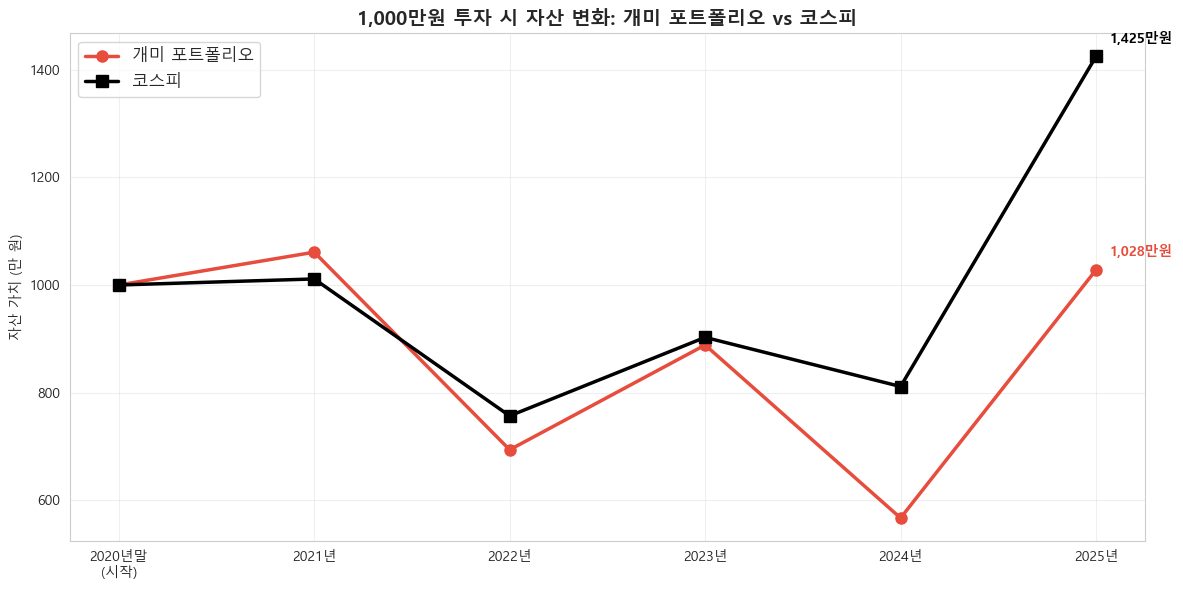

In [4]:
# 누적 수익률 시각화
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(cumul_df))
ax.plot(x, cumul_df['개미포트폴리오'], 'o-', color='#e74c3c', linewidth=2.5, 
        markersize=8, label='개미 포트폴리오')
ax.plot(x, cumul_df['코스피'], 's-', color='black', linewidth=2.5, 
        markersize=8, label='코스피')

ax.set_xticks(x)
ax.set_xticklabels(cumul_df['연도'].apply(lambda v: f"{v}년" if v != '시작' else '2020년말\n(시작)'))
ax.set_ylabel('자산 가치 (만 원)')
ax.set_title('1,000만원 투자 시 자산 변화: 개미 포트폴리오 vs 코스피', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# 최종 금액 표시
for col, color in [('개미포트폴리오', '#e74c3c'), ('코스피', 'black')]:
    final = cumul_df[col].iloc[-1]
    ax.annotate(f'{final:,.0f}만원', 
                xy=(len(cumul_df)-1, final),
                xytext=(10, 10), textcoords='offset points',
                fontweight='bold', color=color)

plt.tight_layout()
plt.savefig('../images/cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. 왜 개미가 졌는가: 하락장 민감도 분석

개미 포트폴리오가 코스피보다 못한 원인을 분석합니다.
가설: 개미가 선호하는 대형 성장주는 상승장에서 강하지만, 하락장에서 더 크게 빠진다.

In [5]:
# 상승장 vs 하락장에서의 성과 차이
print("=" * 60)
print("시장 상황별 개미 포트폴리오 성과")
print("=" * 60)

up_excess = []
down_excess = []

for _, r in results_df.iterrows():
    if r['코스피수익률'] > 0:
        up_excess.append(r['초과수익률'])
        label = "상승장"
    else:
        down_excess.append(r['초과수익률'])
        label = "하락장"
    
    print(f"  {r['보유연도']:.0f}년 ({label}): 코스피 {r['코스피수익률']:+.1f}% → 초과수익 {r['초과수익률']:+.1f}%p")

print(f"\n상승장 평균 초과수익: {np.mean(up_excess):+.1f}%p ({len(up_excess)}년)")
print(f"하락장 평균 초과수익: {np.mean(down_excess):+.1f}%p ({len(down_excess)}년)")
print(f"\n→ 개미 포트폴리오는 상승장에서 {np.mean(up_excess):+.1f}%p 이기지만")
print(f"  하락장에서 {np.mean(down_excess):+.1f}%p 지면서 전체적으로 손해")

시장 상황별 개미 포트폴리오 성과
  2021년 (상승장): 코스피 +1.1% → 초과수익 +5.0%p
  2022년 (하락장): 코스피 -25.2% → 초과수익 -9.4%p
  2023년 (상승장): 코스피 +19.3% → 초과수익 +8.8%p
  2024년 (하락장): 코스피 -10.1% → 초과수익 -26.1%p
  2025년 (상승장): 코스피 +75.7% → 초과수익 +5.8%p

상승장 평균 초과수익: +6.5%p (3년)
하락장 평균 초과수익: -17.8%p (2년)

→ 개미 포트폴리오는 상승장에서 +6.5%p 이기지만
  하락장에서 -17.8%p 지면서 전체적으로 손해


In [7]:
# 개미가 가장 크게 진 종목 vs 이긴 종목
print("=" * 60)
print("5년간 개미 포트폴리오 종목별 코스피 초과수익 TOP/BOTTOM")
print("=" * 60)

all_stock_results = []
for _, r in results_df.iterrows():
    for s in r['종목상세']:
        s['보유연도'] = r['보유연도']
        s['코스피수익률'] = r['코스피수익률']
        all_stock_results.append(s)

stock_results_df = pd.DataFrame(all_stock_results)

print("\n  코스피 대비 가장 많이 이긴 종목 TOP 5:")
top5 = stock_results_df.nlargest(5, '코스피초과')
for _, row in top5.iterrows():
    print(f"  {row['보유연도']:.0f}년 {row['종목명']:<12} 수익률 {row['수익률']:+.1f}% (코스피 대비 {row['코스피초과']:+.1f}%p)")

print("\n  코스피 대비 가장 많이 진 종목 TOP 5:")
bot5 = stock_results_df.nsmallest(5, '코스피초과')
for _, row in bot5.iterrows():
    print(f"  {row['보유연도']:.0f}년 {row['종목명']:<12} 수익률 {row['수익률']:+.1f}% (코스피 대비 {row['코스피초과']:+.1f}%p)")

5년간 개미 포트폴리오 종목별 코스피 초과수익 TOP/BOTTOM

  코스피 대비 가장 많이 이긴 종목 TOP 5:
  2025년 SK하이닉스       수익률 +280.3% (코스피 대비 +204.6%p)
  2025년 한화오션         수익률 +200.5% (코스피 대비 +124.9%p)
  2023년 SK하이닉스       수익률 +86.9% (코스피 대비 +67.6%p)
  2025년 삼성전자         수익률 +124.5% (코스피 대비 +48.9%p)
  2021년 카카오          수익률 +41.5% (코스피 대비 +40.4%p)

  코스피 대비 가장 많이 진 종목 TOP 5:
  2025년 유한양행         수익률 -5.0% (코스피 대비 -80.7%p)
  2025년 삼성SDI        수익률 +14.9% (코스피 대비 -60.7%p)
  2025년 호텔신라         수익률 +21.7% (코스피 대비 -54.0%p)
  2025년 NAVER        수익률 +25.1% (코스피 대비 -50.5%p)
  2024년 포스코퓨처엠       수익률 -59.6% (코스피 대비 -49.5%p)


## 3. 백테스트 결론

### 핵심 결과

| 지표 | 개미 포트폴리오 | 코스피 |
|------|---------------|--------|
| 5년 누적 수익률 | +2.8% | +42.5% |
| 연평균 수익률 | +9.0% | +12.2% |
| 상승장 평균 초과수익 | +6.5%p | - |
| 하락장 평균 초과수익 | -17.8%p | - |
| 1,000만원 최종 가치 | 1,028만원 | 1,425만원 |

### 왜 개미가 졌는가

1. **비대칭적 리스크**: 상승장에서 소폭 이기고(+6.5%p), 하락장에서 크게 짐(-17.8%p)
2. **대형 성장주 편향**: 삼성전자, SK하이닉스, NAVER 등에 집중 → 하락장에서 시장보다 더 큰 낙폭
3. **고점 추격 매수**: 전년도에 많이 오른 종목을 다음 해에 사는 구조 → 평균 회귀(mean reversion)에 취약